# Pré-Processamento dos dados de entrada da ferramenta operacional
**Objetivo:** Limpeza, seleção de features e interpolação dos dados de entrada para as modelagens.

**Premissas:** 
- Variáveis atmosféricas foram retiradas de reanálises numéricas, logo não foram tratadas em relação a gaps, outliers, etc.
- Eixo temporal padrão -> UTC
- As variáveis foram salvas sem normalização. O modelo utilizado será o LightGBM que não necesssita de normalização.

- Dados de entrada e saída disponíveis em: data/operacao


## 1. Leitura dos dados

In [1]:
%matplotlib widget

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Poluentes e Atmosfera da estação de referencia = estação 08 (Congonhas)

In [3]:
poluentes = pd.read_csv("../data/operational/openaq_location_6139516_240626.csv")
poluentes.head()

,location_id,location_name,parameter,value,unit,datetimeUtc,datetimeLocal,timezone,latitude,longitude,country_iso,isMobile,isMonitor,owner_name,provider
0,6139516,São Paulo,pm1,27.2,µg/m³,2026-05-24T01:00:00Z,2026-05-23T22:00:00-03:00,America/Sao_Paulo,-23.647315,-46.664364,NaN,NaN,NaN,AirGradient,AirGradient
1,6139516,São Paulo,pm1,28.5,µg/m³,2026-05-24T02:00:00Z,2026-05-23T23:00:00-03:00,America/Sao_Paulo,-23.647315,-46.664364,NaN,NaN,NaN,AirGradient,AirGradient
2,6139516,São Paulo,pm1,25.0,µg/m³,2026-05-24T03:00:00Z,2026-05-24T00:00:00-03:00,America/Sao_Paulo,-23.647315,-46.664364,NaN,NaN,NaN,AirGradient,AirGradient
3,6139516,São Paulo,pm1,27.5,µg/m³,2026-05-24T04:00:00Z,2026-05-24T01:00:00-03:00,America/Sao_Paulo,-23.647315,-46.664364,NaN,NaN,NaN,AirGradient,AirGradient
4,6139516,São Paulo,pm1,30.9,µg/m³,2026-05-24T05:00:00Z,2026-05-24T02:00:00-03:00,America/Sao_Paulo,-23.647315,-46.664364,NaN,NaN,NaN,AirGradient,AirGradient


In [4]:
poluentes['parameter'].unique()

array(['pm1', 'pm25', 'relativehumidity', 'temperature', 'um003'],
      dtype=object)

In [5]:
poluentes = (
    poluentes[poluentes["parameter"] == "pm25"]
    .loc[:, ["datetimeLocal", "value"]]
    .rename(columns={
        "datetimeLocal": "time",
        "value": "MP2.5"
    })
)

In [6]:
poluentes.head()

,time,MP2.5
768,2026-05-23T22:00:00-03:00,43.0
769,2026-05-23T23:00:00-03:00,45.0
770,2026-05-24T00:00:00-03:00,39.4
771,2026-05-24T01:00:00-03:00,43.3
772,2026-05-24T02:00:00-03:00,49.2


In [29]:
# simula a conversão do treino em um timestamp de exemplo
exemplo_treino = pd.Timestamp("2026-05-23 22:00:00")
treino_utc = (
    pd.Series([exemplo_treino])
    .dt.tz_localize("Etc/GMT+3")
    .dt.tz_convert("UTC")
    .iloc[0]
)

# converte o novo dado 2026 para UTC
exemplo_2026 = pd.Timestamp("2026-05-23T22:00:00-03:00")
novo_utc = exemplo_2026.tz_convert("UTC")

print(f"Treino  (Etc/GMT+3 → UTC) : {treino_utc}")
print(f"Novo    (-03:00 → UTC)    : {novo_utc}")
print(f"Alinhados: {treino_utc == novo_utc}")

Treino  (Etc/GMT+3 → UTC) : 2026-05-24 01:00:00+00:00
Novo    (-03:00 → UTC)    : 2026-05-24 01:00:00+00:00
Alinhados: True


In [7]:
poluentes.shape

(768, 2)

In [8]:
atmosfera = pd.read_csv("../data/operational/openmeteo_operacional_20260624.csv")
atmosfera.head()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2026-05-22 21:00:00-03:00,14.50,93.722240,0.0,5.920878
1,2026-05-22 22:00:00-03:00,14.10,95.866234,0.0,5.840993
2,2026-05-22 23:00:00-03:00,14.55,95.260030,0.0,7.327127
3,2026-05-23 00:00:00-03:00,14.60,95.881940,0.0,7.970972
4,2026-05-23 01:00:00-03:00,14.90,95.272606,0.0,6.544677


In [9]:
# Dados da CETESB: considerar que estão em horário local de SP -> transformar para UTC
poluentes["time"] = (
    pd.to_datetime(poluentes["time"], utc=True)
)

# Fuso já vem no time -> transformar para UTC
atmosfera["time"] = (
    pd.to_datetime(atmosfera["time"], utc=True)
)

In [10]:
# confirmar mesmo eixo de tempo
print(poluentes["time"].dtype)
print(atmosfera["time"].dtype)

datetime64[ns, UTC]
datetime64[ns, UTC]


In [11]:
atmosfera["time"].diff().value_counts().head(10)

time
0 days 01:00:00    771
Name: count, dtype: int64

In [12]:
poluentes["time"].diff().value_counts().head(10)

time
0 days 01:00:00    767
Name: count, dtype: int64

In [13]:
# juntar os dados pelo horário - Mantendo as variáveis básicas (PM25, temperatura, umidade)
df = pd.merge(
    poluentes[["time", "MP2.5"]],
    atmosfera[["time", "temperature_2m", "relative_humidity_2m","precipitation","wind_speed_10m"]],
    on="time",
    how="inner"
)

df = df.set_index("time")

In [14]:
df.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,,
2026-05-24 01:00:00+00:00,43.0,16.10,97.165480,0.4,3.284691
2026-05-24 02:00:00+00:00,45.0,16.00,98.730400,0.9,5.400000
2026-05-24 03:00:00+00:00,39.4,15.85,97.784970,0.2,7.895416
2026-05-24 04:00:00+00:00,43.3,15.40,98.724525,0.2,3.494968
2026-05-24 05:00:00+00:00,49.2,15.40,98.724525,0.6,2.099143


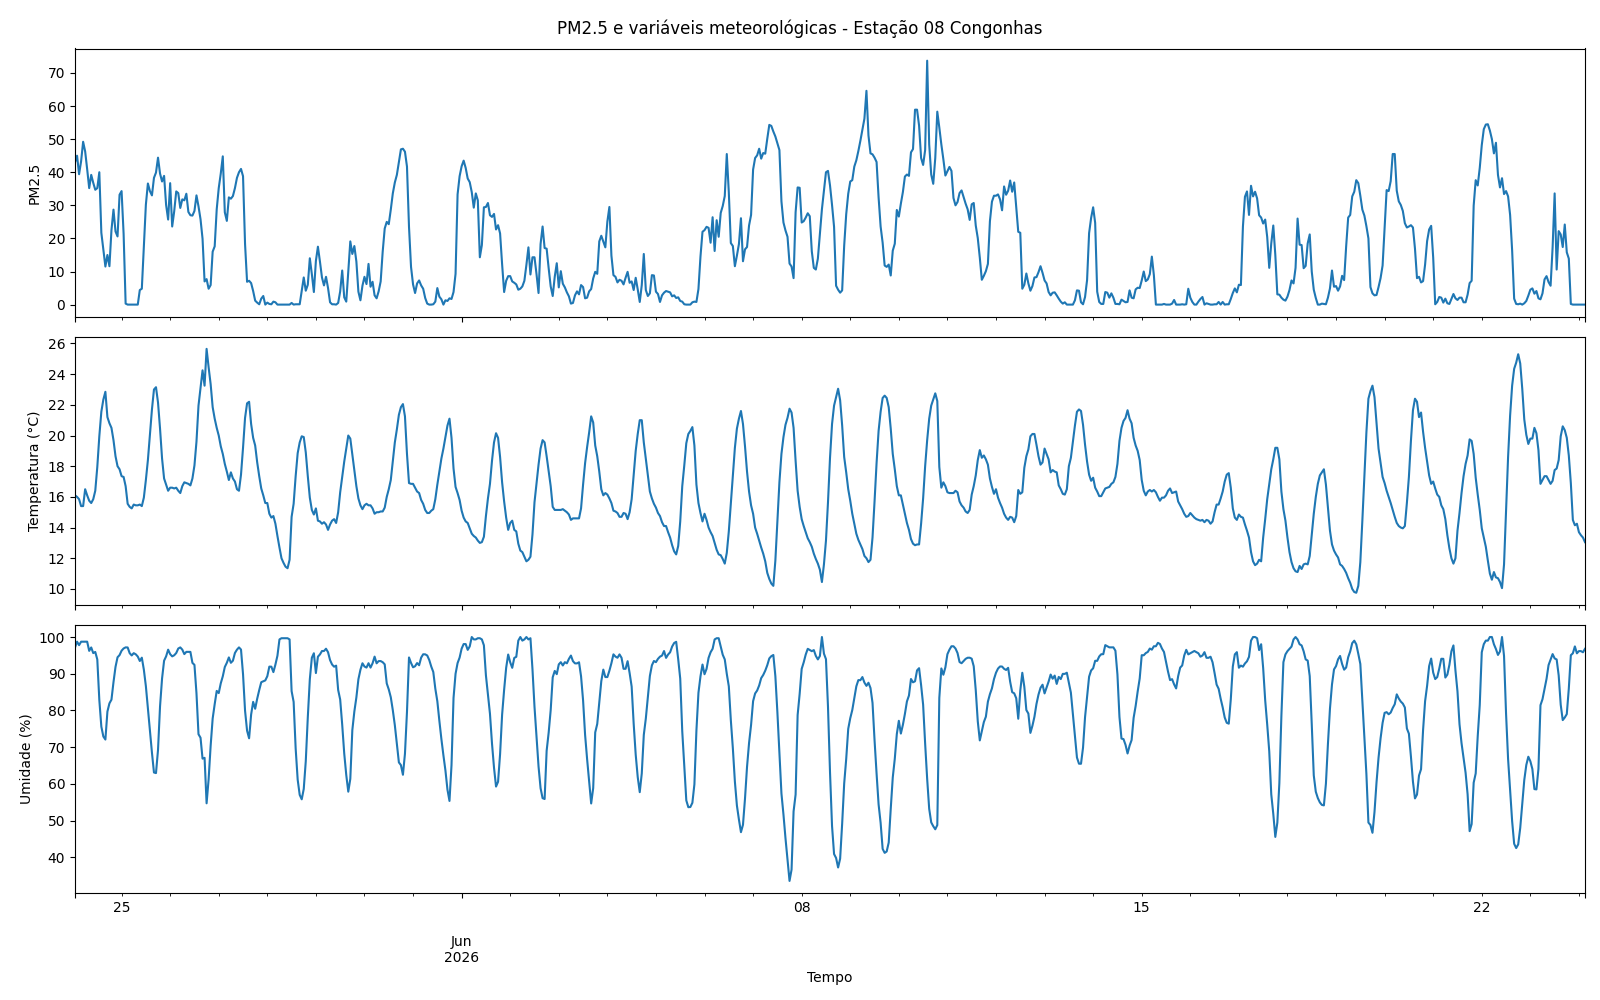

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

df["MP2.5"].plot(ax=axes[0])
axes[0].set_ylabel("PM2.5")

df["temperature_2m"].plot(ax=axes[1])
axes[1].set_ylabel("Temperatura (°C)")

df["relative_humidity_2m"].plot(ax=axes[2])
axes[2].set_ylabel("Umidade (%)")

axes[2].set_xlabel("Tempo")

fig.suptitle("PM2.5 e variáveis meteorológicas - Estação 08 Congonhas")
plt.tight_layout()
plt.show()

In [ ]:
n_zeros = (df["MP2.5"] == 0).sum()
perc_zeros = 100 * n_zeros / len(df)
perc_zeros

np.float64(7.228915662650603)

## 2. Analisando outliers na série de PM25

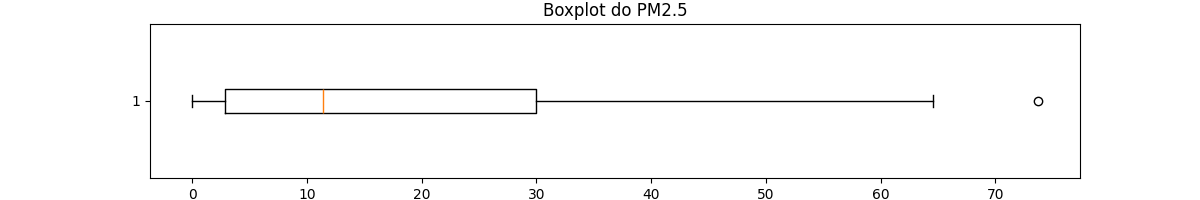

In [17]:
fig, ax = plt.subplots(figsize=(12,2))

ax.boxplot(
    df["MP2.5"].dropna(),
    vert=False
)

ax.set_title("Boxplot do PM2.5")
ax.set_xlabel("PM2.5")

plt.show()

## 3. Analisando gaps temporais de PM2.5 e interpolando

No operacional vou baixar os últimos 30 dias. Dessa forma, vou considerar somente interpolar janelas menores que 12h. Caso tenham janelas maiores vou deixar com o NaN mesmo para aplicação com o lightGBM

In [18]:
df = df.asfreq("H")

gaps = df[df["MP2.5"].isna()]
print(gaps)

Empty DataFrame
Columns: [MP2.5, temperature_2m, relative_humidity_2m, precipitation, wind_speed_10m]
Index: []


/tmp/ipykernel_2762/1545516846.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq("H")


In [19]:
# percentual de dados válidos
completude = df["MP2.5"].notna().mean() * 100

print(f"Completude = {completude:.1f}%")

Completude = 100.0%


In [20]:
def interpolar_gaps_temporais(df, coluna="MP2.5", limite_gap=12):
    """
    Interpola gaps temporais consecutivos de até `limite_gap` amostras.

    """

    df = df.copy()

    # Se não tem gap, nada muda.
    if not df[coluna].isna().any():
        print(f"Nenhum gap encontrado em {coluna}.")
        return df

    serie_interp = df[coluna].copy()

    is_nan = df[coluna].isna()
    grupos = (is_nan != is_nan.shift()).cumsum()

    for _, grupo in df[coluna].groupby(grupos):

        if grupo.isna().all():

            tamanho_gap = len(grupo)

            if tamanho_gap <= limite_gap:

                inicio = grupo.index[0]
                fim = grupo.index[-1]

                serie_interp.loc[inicio:fim] = (
                    df[coluna]
                    .interpolate(method="time", limit_area="inside")
                    .loc[inicio:fim]
                )

    df[coluna] = serie_interp

    return df

In [21]:
df = interpolar_gaps_temporais(df, coluna="MP2.5", limite_gap=12)

Nenhum gap encontrado em MP2.5.


In [22]:
df.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,,
2026-05-24 01:00:00+00:00,43.0,16.10,97.165480,0.4,3.284691
2026-05-24 02:00:00+00:00,45.0,16.00,98.730400,0.9,5.400000
2026-05-24 03:00:00+00:00,39.4,15.85,97.784970,0.2,7.895416
2026-05-24 04:00:00+00:00,43.3,15.40,98.724525,0.2,3.494968
2026-05-24 05:00:00+00:00,49.2,15.40,98.724525,0.6,2.099143


### 4. Feature Engineering

In [23]:
def cyclical_time_features(df):
    """
    Adiciona termos ciclicos como features exógenas
    df -> data

    """

    df = df.copy()

    df["month_sin"] = np.sin(2 * np.pi * df.index.month / 12)
    df["month_cos"] = np.cos(2 * np.pi * df.index.month / 12)


    df["weekday_sin"] = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df.index.dayofweek / 7)


    df["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24)

    return df

In [24]:
data_lgbm = cyclical_time_features(df)

In [25]:
data_lgbm.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,hour_cos
time,,,,,,,,,,,
2026-05-24 01:00:00+00:00,43.0,16.10,97.165480,0.4,3.284691,0.5,-0.866025,-0.781831,0.62349,0.258819,0.965926
2026-05-24 02:00:00+00:00,45.0,16.00,98.730400,0.9,5.400000,0.5,-0.866025,-0.781831,0.62349,0.500000,0.866025
2026-05-24 03:00:00+00:00,39.4,15.85,97.784970,0.2,7.895416,0.5,-0.866025,-0.781831,0.62349,0.707107,0.707107
2026-05-24 04:00:00+00:00,43.3,15.40,98.724525,0.2,3.494968,0.5,-0.866025,-0.781831,0.62349,0.866025,0.500000
2026-05-24 05:00:00+00:00,49.2,15.40,98.724525,0.6,2.099143,0.5,-0.866025,-0.781831,0.62349,0.965926,0.258819


In [26]:
met_vars = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
]

for var in met_vars:
    if var in data_lgbm.columns:
        for lag in [1, 3, 6, 12, 24]:
            data_lgbm[f"{var}_lag{lag}"] = data_lgbm[var].shift(lag)

data_lgbm.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,...,relative_humidity_2m_lag1,relative_humidity_2m_lag3,relative_humidity_2m_lag6,relative_humidity_2m_lag12,relative_humidity_2m_lag24,wind_speed_10m_lag1,wind_speed_10m_lag3,wind_speed_10m_lag6,wind_speed_10m_lag12,wind_speed_10m_lag24
time,,,,,,,,,,,,,,,,,,,,,
2026-05-24 01:00:00+00:00,43.0,16.10,97.165480,0.4,3.284691,0.5,-0.866025,-0.781831,0.62349,0.258819,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-24 02:00:00+00:00,45.0,16.00,98.730400,0.9,5.400000,0.5,-0.866025,-0.781831,0.62349,0.500000,...,97.165480,NaN,NaN,NaN,NaN,3.284691,NaN,NaN,NaN,NaN
2026-05-24 03:00:00+00:00,39.4,15.85,97.784970,0.2,7.895416,0.5,-0.866025,-0.781831,0.62349,0.707107,...,98.730400,NaN,NaN,NaN,NaN,5.400000,NaN,NaN,NaN,NaN
2026-05-24 04:00:00+00:00,43.3,15.40,98.724525,0.2,3.494968,0.5,-0.866025,-0.781831,0.62349,0.866025,...,97.784970,97.16548,NaN,NaN,NaN,7.895416,3.284691,NaN,NaN,NaN
2026-05-24 05:00:00+00:00,49.2,15.40,98.724525,0.6,2.099143,0.5,-0.866025,-0.781831,0.62349,0.965926,...,98.724525,98.73040,NaN,NaN,NaN,3.494968,5.400000,NaN,NaN,NaN


In [27]:
for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
    data_lgbm[f"pm25_lag{lag}"] = data_lgbm["MP2.5"].shift(lag)

data_lgbm.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,...,wind_speed_10m_lag12,wind_speed_10m_lag24,pm25_lag1,pm25_lag2,pm25_lag3,pm25_lag6,pm25_lag12,pm25_lag24,pm25_lag48,pm25_lag168
time,,,,,,,,,,,,,,,,,,,,,
2026-05-24 01:00:00+00:00,43.0,16.10,97.165480,0.4,3.284691,0.5,-0.866025,-0.781831,0.62349,0.258819,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-24 02:00:00+00:00,45.0,16.00,98.730400,0.9,5.400000,0.5,-0.866025,-0.781831,0.62349,0.500000,...,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-24 03:00:00+00:00,39.4,15.85,97.784970,0.2,7.895416,0.5,-0.866025,-0.781831,0.62349,0.707107,...,NaN,NaN,45.0,43.0,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-24 04:00:00+00:00,43.3,15.40,98.724525,0.2,3.494968,0.5,-0.866025,-0.781831,0.62349,0.866025,...,NaN,NaN,39.4,45.0,43.0,NaN,NaN,NaN,NaN,NaN
2026-05-24 05:00:00+00:00,49.2,15.40,98.724525,0.6,2.099143,0.5,-0.866025,-0.781831,0.62349,0.965926,...,NaN,NaN,43.3,39.4,45.0,NaN,NaN,NaN,NaN,NaN


In [28]:
data_lgbm["is_winter"] = data_lgbm.index.month.isin([6, 7, 8]).astype(int)
data_lgbm.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,...,wind_speed_10m_lag24,pm25_lag1,pm25_lag2,pm25_lag3,pm25_lag6,pm25_lag12,pm25_lag24,pm25_lag48,pm25_lag168,is_winter
time,,,,,,,,,,,,,,,,,,,,,
2026-05-24 01:00:00+00:00,43.0,16.10,97.165480,0.4,3.284691,0.5,-0.866025,-0.781831,0.62349,0.258819,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2026-05-24 02:00:00+00:00,45.0,16.00,98.730400,0.9,5.400000,0.5,-0.866025,-0.781831,0.62349,0.500000,...,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2026-05-24 03:00:00+00:00,39.4,15.85,97.784970,0.2,7.895416,0.5,-0.866025,-0.781831,0.62349,0.707107,...,NaN,45.0,43.0,NaN,NaN,NaN,NaN,NaN,NaN,0
2026-05-24 04:00:00+00:00,43.3,15.40,98.724525,0.2,3.494968,0.5,-0.866025,-0.781831,0.62349,0.866025,...,NaN,39.4,45.0,43.0,NaN,NaN,NaN,NaN,NaN,0
2026-05-24 05:00:00+00:00,49.2,15.40,98.724525,0.6,2.099143,0.5,-0.866025,-0.781831,0.62349,0.965926,...,NaN,43.3,39.4,45.0,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
for window in [6, 12, 24, 48]:
    base = data_lgbm["MP2.5"].shift(1)
    data_lgbm[f"pm25_mean_{window}h"] = base.rolling(window).mean()
    data_lgbm[f"pm25_std_{window}h"]  = base.rolling(window).std()
    data_lgbm[f"pm25_max_{window}h"]  = base.rolling(window).max()

data_lgbm.shape

(747, 47)

In [ ]:
#salvar
data_lgbm.to_csv(
   "../data/operational/dados_features_engineering_gaps_UTC_20260624.csv",
   index=True
)